In [1]:
## generate a CSV file that can be saved to a usb drive and loaded onto the AFG 2225

import numpy as np
import matplotlib.pyplot as plt
import codecs

In [2]:
## generate noise in some bandwidth

playback_freq = 0.1 ## Hz, frequency to cycle through the arb waveform
npts = 2**12 ## number of points in the arb waveform

start_freq = 25 ## Hz, start frequency of the noise
stop_freq = 35 ## Hz, stop frequency of the noise

nyquist_freq = 0.5 * playback_freq * npts ## Nyquist frequency
freq_vec = np.linspace(0, nyquist_freq, int(npts/2)+1) ## frequency vector

noise_tilde_orig = np.zeros(int(npts/2 +1), dtype=np.complex128) ## initialize the noise vector
noise_tilde_orig[(freq_vec >= start_freq) & (freq_vec <= stop_freq)] = 1 ## noise in the desired bandwidth

num_phase_opts = 100000 ## number of random phases to try
best_opt = 1e20
best_vec = np.zeros(npts)
for i in range(num_phase_opts):
    phase_vec = 2 * np.pi * np.random.rand(int(npts/2)+1) ## random phase vector
    noise_tilde = noise_tilde_orig * np.exp(1j * phase_vec) ## multiply by the random phase vector
    noise_vec = np.fft.irfft(noise_tilde) ## inverse FFT to get the time domain waveform

    curr_max = np.max(np.abs(noise_vec))
    if curr_max < best_opt:
        print("Current smallest amp = ",  curr_max)
        best_opt = curr_max
        best_vec = noise_vec

## normalize the noise vector to have a maximum amplitude of 511
best_vec = best_vec / np.max(np.abs(best_vec)) * 511

outfile = codecs.open("white_noise_25_35_0.1.csv", "w", "utf-8") ## open the output file
outfile.write("Start:,0,\n") ## write the header
outfile.write("Length:,4096,\n")
outfile.write("Sample Rate:,100,\n")
for i in range(npts):
    outfile.write("%d,\n"%best_vec[i]) ## write the noise vector to the file
outfile.write("\n")
outfile.close()
#np.savetxt("white_noise_1_50_0.1.csv", np.atleast_2d(best_vec), delimiter=",", fmt="%d") ## save the noise vector to a CSV file


Current smallest amp =  0.01153304062688823
Current smallest amp =  0.010661353593839809
Current smallest amp =  0.010548740399944644
Current smallest amp =  0.010159263444146827
Current smallest amp =  0.0095471238557468
Current smallest amp =  0.009342787633297198
Current smallest amp =  0.009191289877581738
Current smallest amp =  0.008935204282239415
Current smallest amp =  0.008799596921296497


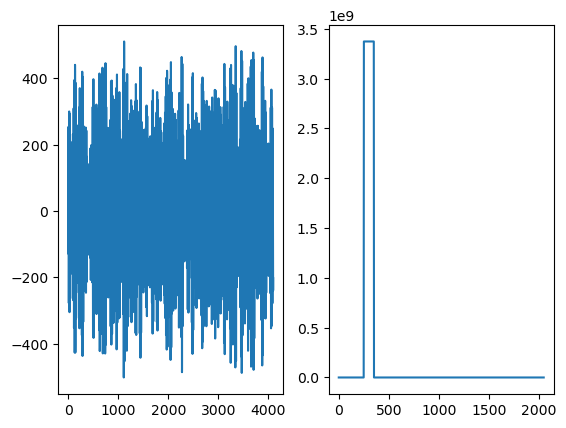

In [3]:
plt.figure()
plt.subplot(1,2,1)
plt.plot(best_vec)
plt.subplot(1,2,2)
plt.plot(np.abs(np.fft.rfft(best_vec))**2)
plt.show()